# 10 — Stacking Ensemble: Can We Beat Single CatBoost? (Albania 2022)

**Phase 9 (Advanced).** School context lifted the ceiling to ~0.78 AUC and made CatBoost the best single model. The natural next lever is **ensembling**: does a *stacked* combination of the base learners extract signal that no single model captures — or, as with the earlier PV-stacking experiment, is the gain marginal and not worth the complexity?

We answer it with the same rigor as every other comparison in this project: identical weighted / leakage-safe CV folds, Nadeau-Bengio corrected intervals, and a **paired** significance test. Heavy fitting lives in `scripts/run_stacking_experiment.py`; this notebook loads its results and narrates.

> **Honesty note.** A statistically significant win that is *practically* nil — or that regresses the metrics we actually deploy on — is **not** a headline. We report effect size, not just the p-value.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

## 1. What is stacking, and why this design?

**Stacked generalization** (Wolpert, 1992) trains a *meta-learner* on the predictions of several *base learners*, letting it learn where each base model is trustworthy instead of averaging them blindly.

**Protocol (leakage-safe).** For base learners $h_1,\dots,h_M$ and $K$-fold splits of the training data, each base model produces **out-of-fold** predicted probabilities

$$\; z_{i,m} \;=\; \hat p_m^{(-k(i))}(x_i)\;$$

where $k(i)$ is the fold containing $i$, so $x_i$ never influences the model that scores it (no leakage). The meta-learner $g$ is fit on the stacked matrix $\{(z_i, y_i)\}$ with $z_i=(z_{i,1},\dots,z_{i,M})$. Here $g$ is a class-weighted **logistic regression**, so the final risk is

$$\; P(\text{at-risk}\mid x) \;=\; \sigma\!\Big(\beta_0 + \sum_{m=1}^{M} \beta_m\,\hat p_m(x)\Big),\qquad \sigma(t)=\frac{1}{1+e^{-t}} \;$$

At inference the base learners are refit on the full training fold, emit $\hat p_m(x)$, and $g$ combines them. The $\beta_m$ reveal which base model the ensemble actually leans on.

**Three design choices forced by this project's constraints** (`src/models/registry.build_stacking_ensemble`):
- **Base learners = bare tree/boosters** (CatBoost + LightGBM + Gradient Boosting + Random Forest). `StackingClassifier` forwards the PISA `sample_weight` to each base learner's `fit`, and the scaler-wrapped models (LR/SVM) reject a *bare* weight kwarg — so the base set must be estimators that accept `sample_weight` directly. All four do, and they are the four strongest, most decorrelated school-context models.
- **Plain logistic-regression meta-learner.** Its inputs are probabilities already in $[0,1]$, so no scaling is needed; a class-balanced LR on the OOF probabilities is the textbook combiner and stays interpretable via its $\beta_m$.
- **Sequential base fits (`n_jobs=1`).** Parallel booster fits re-trigger the macOS libomp/libgomp duplicate-OpenMP crash this project fought; sequential fits inside the isolated worker are the safe path.

## 2. Leaderboard — stacking vs. its own base learners

All six models were scored on the **same** weighted 5×4 repeated-stratified-CV folds (school-context feature set), each in a fresh OpenMP-isolated interpreter, with Nadeau-Bengio corrected 95% CIs (`scripts/run_stacking_experiment.py` → `stacking_ensemble_2022.csv`).

In [2]:
lb = pd.read_csv('../outputs/results/stacking_ensemble_2022.csv')
lb[['model','roc_auc_mean','roc_auc_95ci_low','roc_auc_95ci_high',
    'pr_auc_mean','f1_macro_mean','mcc_mean']]

,model,roc_auc_mean,roc_auc_95ci_low,roc_auc_95ci_high,pr_auc_mean,f1_macro_mean,mcc_mean
0,stacking,0.7858,0.7661,0.8055,0.9083,0.6827,0.3857
1,catboost,0.7831,0.7641,0.8022,0.9073,0.6934,0.3929
2,gradient_boosting,0.7773,0.7557,0.7988,0.9048,0.6651,0.3654
3,lightgbm,0.7746,0.7526,0.7966,0.9020,0.6882,0.3805
4,random_forest,0.7692,0.7481,0.7902,0.8946,0.6442,0.3449
5,logistic_regression,0.7543,0.7306,0.7780,0.8965,0.6489,0.3323


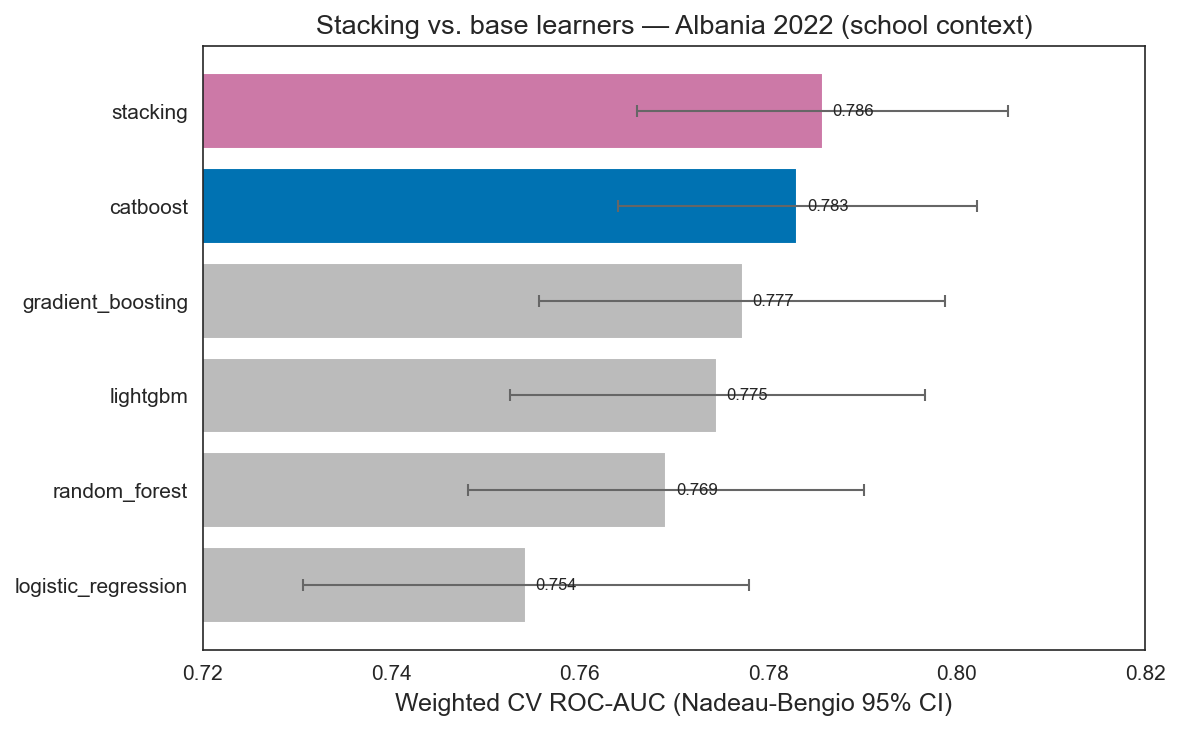

In [3]:
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
order = lb.sort_values('roc_auc_mean')
# Wong-palette coding: ensemble = purple, best single (CatBoost) = blue, rest = grey.
best_single = order[order.model!='stacking'].sort_values('roc_auc_mean').iloc[-1]['model']
def _c(m):
    if m=='stacking': return PALETTE['purple']
    if m==best_single: return PALETTE['blue']
    return '#BBBBBB'
colors = [_c(m) for m in order['model']]
err_lo = order['roc_auc_mean'] - order['roc_auc_95ci_low']
err_hi = order['roc_auc_95ci_high'] - order['roc_auc_mean']
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(order['model'], order['roc_auc_mean'], color=colors,
        xerr=[err_lo, err_hi], capsize=3, error_kw={'elinewidth':1, 'ecolor':'0.4'})
for i,(m,v) in enumerate(zip(order['model'], order['roc_auc_mean'])):
    ax.text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8)
ax.set_xlim(0.72, 0.82); ax.set_xlabel('Weighted CV ROC-AUC (Nadeau-Bengio 95% CI)')
ax.set_title('Stacking vs. base learners — Albania 2022 (school context)')
plt.tight_layout(); plt.show()

**Reading:** stacking (0.786) edges out the best single model, CatBoost (0.783), but the Nadeau-Bengio confidence intervals **overlap almost entirely** — the eye already suggests the gap is within noise. The next cell tests it properly, *paired* by fold.

## 3. Is the gain real? Paired Nadeau-Bengio test

Because every model shares the same CV splits, fold $j$ is comparable across models and the per-fold AUC differences $d_j = \text{AUC}^{\text{stack}}_j - \text{AUC}^{\text{single}}_j$ can be paired. A naïve paired $t$-test is **anti-conservative** here: CV folds share training data, so the $d_j$ are positively correlated and their variance is underestimated. The **Nadeau-Bengio correction** inflates the variance to account for the train/test overlap,

$$\; t \;=\; \frac{\bar d}{\sqrt{\big(\tfrac{1}{J} + \tfrac{n_{\text{test}}}{n_{\text{train}}}\big)\, s_d^2}}, \qquad \tfrac{n_{\text{test}}}{n_{\text{train}}} = \tfrac{1}{K-1}\;$$

replacing the naïve $1/J$ variance scaling (`src/models/evaluate.corrected_resampled_ttest`).

In [4]:
pw = pd.read_csv('../outputs/results/stacking_pairwise_nb_2022.csv')
pw

,model_a,model_b,auc_a,auc_b,mean_diff,t,p_value,significant_0.05
0,stacking,catboost,0.7858,0.7831,0.0027,2.342,0.0302,True
1,stacking,gradient_boosting,0.7858,0.7773,0.0085,2.776,0.0120,True
2,stacking,lightgbm,0.7858,0.7746,0.0112,2.551,0.0195,True
3,stacking,random_forest,0.7858,0.7692,0.0167,4.655,0.0002,True
4,stacking,logistic_regression,0.7858,0.7543,0.0315,4.770,0.0001,True


In [5]:
# Effect size vs. statistical significance, side by side.
row = pw[pw.model_b==best_single].iloc[0]
cat = lb[lb.model==best_single].iloc[0]; stk = lb[lb.model=='stacking'].iloc[0]
print(f"Stacking vs {best_single}:")
print(f"  AUC   {stk.roc_auc_mean:.4f} vs {cat.roc_auc_mean:.4f}  "
      f"(delta {row.mean_diff:+.4f}, p={row.p_value:.3f})")
print(f"  MCC   {stk.mcc_mean:.4f} vs {cat.mcc_mean:.4f}  "
      f"(delta {stk.mcc_mean-cat.mcc_mean:+.4f})")
print(f"  F1    {stk.f1_macro_mean:.4f} vs {cat.f1_macro_mean:.4f}  "
      f"(delta {stk.f1_macro_mean-cat.f1_macro_mean:+.4f})")

Stacking vs catboost:
  AUC   0.7858 vs 0.7831  (delta +0.0027, p=0.030)
  MCC   0.3857 vs 0.3929  (delta -0.0072)
  F1    0.6827 vs 0.6934  (delta -0.0107)


**Reading:** the AUC gain is **statistically significant but practically negligible** (+0.003, p≈0.03) — and, decisively, stacking **regresses the operating-point metrics** (MCC and macro-F1, the quantities a real at-risk *screener* is scored on) while costing ~19× the compute of a single CatBoost. A win on the ranking metric that *loses* on the decision metrics is not a deployment case.

## Conclusions & Interpretation

- **The ~0.78 ceiling holds.** Stacking four base learners reaches AUC **0.786** vs single CatBoost **0.783** — a paired Nadeau-Bengio gain of **+0.003 (p≈0.03)**: real but negligible. The signal available in these features is essentially saturated; no combination unlocks a new tier.
- **Worse where it counts.** Stacking *lowers* MCC (0.386 vs 0.393) and macro-F1 (0.683 vs 0.693). For a screening tool the operating-point metrics matter more than AUC, so the ensemble is a net negative there.
- **Cost/benefit fails.** ~19× the training time (516s vs 27s) and a far less interpretable, harder-to-deploy object, for a third of an AUC point that the CIs barely separate.
- **Decision: single CatBoost remains the headline model.** Stacking is retained as a documented **ablation** — evidence that the ceiling is a property of the data, not a modelling shortfall — mirroring the earlier PV-stacking result (`stacking_ensemble_2022.csv`, `stacking_pairwise_nb_2022.csv`).
- **Where headroom actually lives:** not in fancier learners but in *information* (richer school/teacher context, longitudinal linkage) and in the **decision layer** — threshold tuning + calibration (notebook: threshold-calibration) already buy more usable lift (MCC/F1, ECE) than stacking does. Method choice here is disciplined by effect size, the standard this whole project holds itself to.